In [ ]:
!pip install tensorflow=='2.15' --quiet

## Libraries

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive/')

Drive already mounted at /content/gdrive/; to attempt to forcibly remount, call drive.mount("/content/gdrive/", force_remount=True).


In [ ]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import (Conv2D, BatchNormalization, ReLU, Add,
                                     GlobalAveragePooling2D, Dense, Input,
                                     Concatenate, Layer, Maximum, Multiply)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import ImageFile

## Model Parameters

In [ ]:
IMG_HEIGHT = 256
IMG_WIDTH = 256
CHANNELS = 3
INPUT_SHAPE = (IMG_HEIGHT, IMG_WIDTH, CHANNELS)
IMG_SIZE = (IMG_HEIGHT, IMG_WIDTH)

BATCH_SIZE = 16
N_EPOCHS = 100
LR = 1e-3

VALUE_DT = 0.2
PATH_DIR = ''

ImageFile.LOAD_TRUNCATED_IMAGES = True

## Model Functions

In [ ]:
class RGBtoHSV(Layer):
    def __init__(self, **kwargs):
        super(RGBtoHSV, self).__init__(**kwargs)

    def call(self, inputs):
        return tf.image.rgb_to_hsv(inputs)

    def get_config(self):
        config = super(RGBtoHSV, self).get_config()
        return config

class RGBtoYCbCr(Layer):
    def __init__(self, **kwargs):
        super(RGBtoYCbCr, self).__init__(**kwargs)

    def call(self, inputs):

        rgb_to_ycbcr_kernel = tf.constant([[0.299, 0.587, 0.114],
                                           [-0.1687, -0.3313, 0.5],
                                           [0.5, -0.4187, -0.0813]])
        offset = tf.constant([0, 128/255, 128/255], dtype=tf.float32)
        ycbcr = tf.tensordot(inputs, rgb_to_ycbcr_kernel, axes=[[3], [1]]) + offset

        return ycbcr

    def get_config(self):
        config = super(RGBtoYCbCr, self).get_config()
        return config

In [ ]:
class FuzzyPooling(Layer):
    def __init__(self, pool_size=(2, 2), strides=None, padding='VALID', fuzzy_k=2, **kwargs):
        super(FuzzyPooling, self).__init__(**kwargs)
        self.pool_size = pool_size
        self.strides = strides if strides is not None else pool_size
        self.padding = padding.upper()
        self.fuzzy_k = fuzzy_k

    def call(self, inputs):

        patches = tf.image.extract_patches(
            images=inputs,
            sizes=[1, self.pool_size[0], self.pool_size[1], 1],
            strides=[1, self.strides[0], self.strides[1], 1],
            rates=[1, 1, 1, 1],
            padding=self.padding
        )

        batch_size = tf.shape(inputs)[0]
        new_height = tf.shape(patches)[1]
        new_width = tf.shape(patches)[2]
        channels = inputs.shape[-1]
        patch_dim = self.pool_size[0] * self.pool_size[1]

        patches = tf.reshape(patches, [batch_size, new_height, new_width, channels, patch_dim])


        max_vals = tf.reduce_max(patches, axis=-1, keepdims=True)
        min_vals = tf.reduce_min(patches, axis=-1, keepdims=True)
        denom = max_vals - min_vals + 1e-6

        membership = 1 - tf.abs(patches - max_vals) / denom
        membership = tf.pow(membership, self.fuzzy_k)

        numerator = tf.reduce_sum(patches * membership, axis=-1)
        denominator = tf.reduce_sum(membership, axis=-1) + 1e-6
        fuzzy_pool = numerator / denominator

        return fuzzy_pool

    def compute_output_shape(self, input_shape):

        if self.padding == 'VALID':
            out_height = (input_shape[1] - self.pool_size[0]) // self.strides[0] + 1
            out_width = (input_shape[2] - self.pool_size[1]) // self.strides[1] + 1
        elif self.padding == 'SAME':
            out_height = (input_shape[1] + self.strides[0] - 1) // self.strides[0]
            out_width = (input_shape[2] + self.strides[1] - 1) // self.strides[1]
        else:
            raise ValueError(f"Invalid padding type: {self.padding}")

        return (input_shape[0], out_height, out_width, input_shape[3])

    def get_config(self):

        config = super(FuzzyPooling, self).get_config()
        config.update({
            'pool_size': self.pool_size,
            'strides': self.strides,
            'padding': self.padding,
            'fuzzy_k': self.fuzzy_k,
        })
        return config

In [ ]:
class GlobalFuzzyPooling2D(Layer):
    def __init__(self, fuzzy_k=2, **kwargs):
        super(GlobalFuzzyPooling2D, self).__init__(**kwargs)
        self.fuzzy_k = fuzzy_k

    def call(self, inputs):

        batch_size = tf.shape(inputs)[0]
        height = tf.shape(inputs)[1]
        width = tf.shape(inputs)[2]
        channels = inputs.shape[3]

        inputs_flat = tf.reshape(inputs, [batch_size, height * width, channels])

        max_vals = tf.reduce_max(inputs_flat, axis=1, keepdims=True)
        min_vals = tf.reduce_min(inputs_flat, axis=1, keepdims=True)
        denom = max_vals - min_vals + 1e-6

        membership = 1 - tf.abs(inputs_flat - max_vals) / denom
        membership = tf.pow(membership, self.fuzzy_k)

        numerator = tf.reduce_sum(inputs_flat * membership, axis=1)
        denominator = tf.reduce_sum(membership, axis=1) + 1e-6
        fuzzy_global_pool = numerator / denominator

        return fuzzy_global_pool

    def compute_output_shape(self, input_shape):

        return (input_shape[0], input_shape[3])

    def get_config(self):

        config = super(GlobalFuzzyPooling2D, self).get_config()
        config.update({
            'fuzzy_k': self.fuzzy_k,
        })
        return config

In [ ]:
def residual_block(x, filters, stride=1):
    shortcut = x

    x = Conv2D(filters, kernel_size=(3, 3), strides=stride, padding="same")(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    x = Conv2D(filters, kernel_size=(3, 3), strides=1, padding="same")(x)
    x = BatchNormalization()(x)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = Conv2D(filters, kernel_size=(1, 1), strides=stride, padding="same")(shortcut)
        shortcut = BatchNormalization()(shortcut)

    x = Add()([x, shortcut])
    x = ReLU()(x)

    return x

In [ ]:
def backbone_resnet18(x):
    x = Conv2D(64, kernel_size=(7, 7), strides=2, padding="same")(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    x = FuzzyPooling(pool_size=(3, 3), strides=(2, 2), padding='SAME')(x)

    x = residual_block(x, 64, stride=1)
    x = residual_block(x, 64, stride=1)

    x = residual_block(x, 128, stride=2)
    x = residual_block(x, 128, stride=1)

    x = residual_block(x, 256, stride=2)
    x = residual_block(x, 256, stride=1)

    x = residual_block(x, 512, stride=2)
    x = residual_block(x, 512, stride=1)

    return x

In [ ]:
def phd_resnet18(input_shape=INPUT_SHAPE):
    inputs = Input(shape=input_shape)

    hsv_image = RGBtoHSV()(inputs)

    ycbcr_image = RGBtoYCbCr()(inputs)

    concatenated_inputs = Concatenate()([inputs, hsv_image, ycbcr_image])

    paper_branch = backbone_resnet18(concatenated_inputs)
    replay_branch = backbone_resnet18(concatenated_inputs)
    mask_branch = backbone_resnet18(concatenated_inputs)

    liveness_branch = backbone_resnet18(concatenated_inputs)

    x = GlobalFuzzyPooling2D()(paper_branch)

    paper_output = Dense(2, activation='softmax', name='paper_output')(x)

    x = GlobalFuzzyPooling2D()(replay_branch)
    replay_output = Dense(2, activation='softmax', name='replay_output')(x)

    x = GlobalFuzzyPooling2D()(mask_branch)
    mask_output = Dense(2, activation='softmax', name='mask_output')(x)

    x = GlobalFuzzyPooling2D()(liveness_branch)
    liveness_output = Dense(2, activation='softmax', name='liveness_output')(x)

    concatenated_spoofs = Multiply()([paper_branch, replay_branch, mask_branch])

    x = Conv2D(512, kernel_size=(3, 3), padding="same")(concatenated_spoofs)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    concatenated_liveness = Concatenate()([x, liveness_branch])

    x = Conv2D(512, kernel_size=(3, 3), padding="same")(concatenated_liveness)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    x = GlobalFuzzyPooling2D()(x)
    liveness_final_output = Dense(2, activation='softmax', name='liveness_final_output')(x)

    model = tf.keras.models.Model(inputs, [paper_output, replay_output, mask_output, liveness_output, liveness_final_output])
    return model


## Build Model

In [ ]:
model = phd_resnet18()

optimizer_model = Adam(learning_rate=LR)
model.compile(optimizer=optimizer_model, loss='categorical_crossentropy',
              metrics='accuracy',
              )

model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 256, 256, 3)]        0         []                            
                                                                                                  
 rg_bto_hsv (RGBtoHSV)       (None, 256, 256, 3)          0         ['input_1[0][0]']             
                                                                                                  
 rg_bto_y_cb_cr (RGBtoYCbCr  (None, 256, 256, 3)          0         ['input_1[0][0]']             
 )                                                                                                
                                                                                                  
 concatenate (Concatenate)   (None, 256, 256, 9)          0         ['input_1[0][0]',         

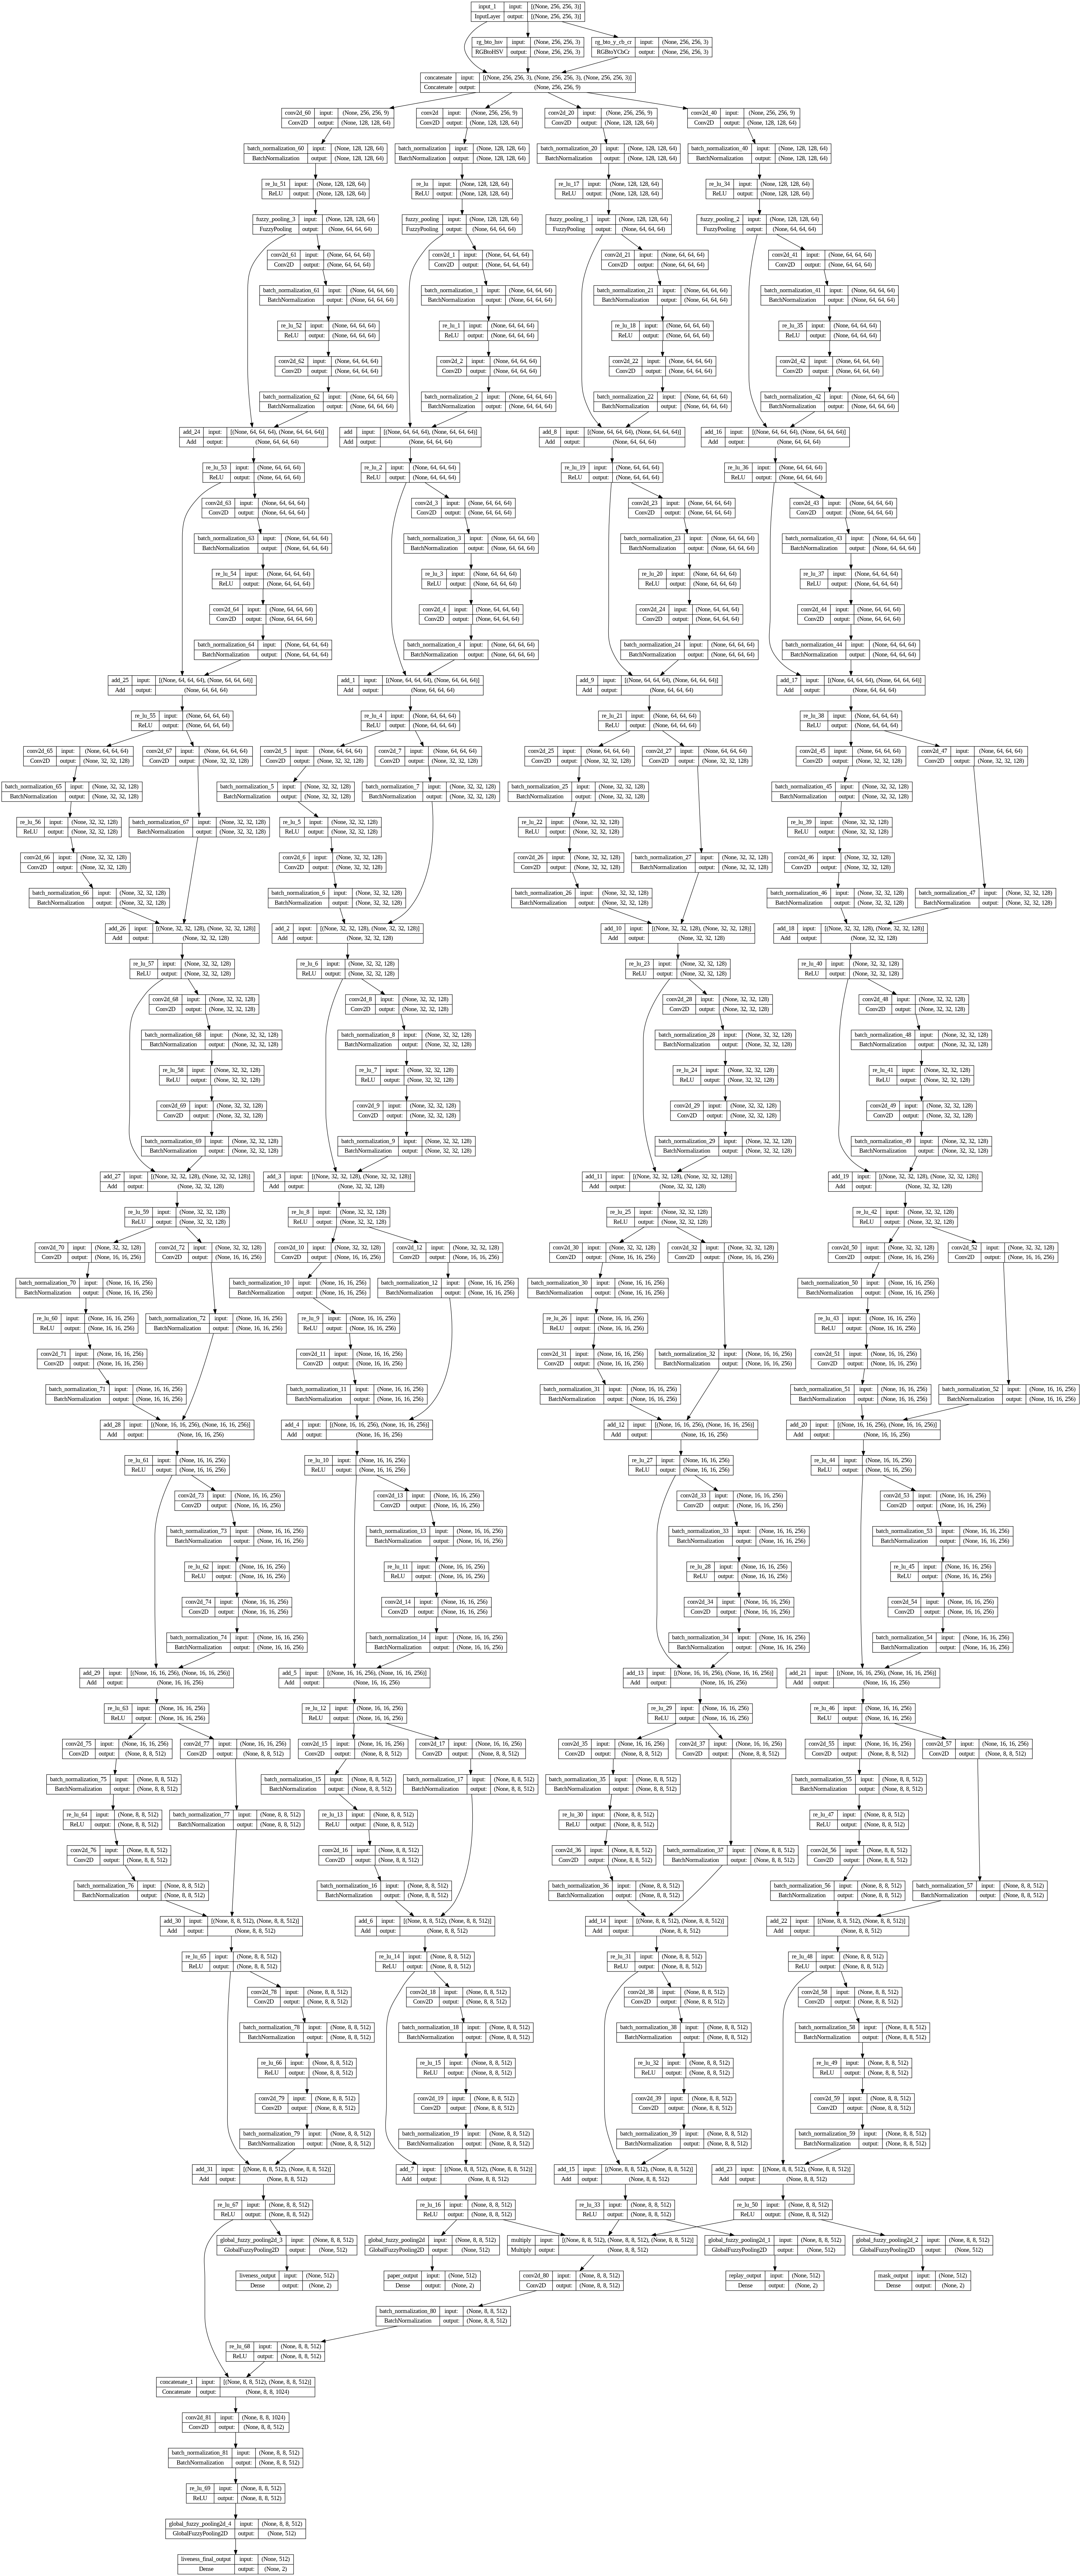

In [ ]:
model.save('model.keras')
dot_img_file = '/tmp/model_1.png'
tf.keras.utils.plot_model(model, to_file=dot_img_file, show_shapes=True)

In [ ]:
model_loaded = tf.keras.models.load_model('model.keras', custom_objects={
                                        'RGBtoHSV': RGBtoHSV,
                                       'RGBtoYCbCr': RGBtoYCbCr,
                                       'FuzzyPooling': FuzzyPooling,
                                       'GlobalFuzzyPooling2D': GlobalFuzzyPooling2D,
})
model_loaded.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 256, 256, 3)]        0         []                            
                                                                                                  
 rg_bto_hsv (RGBtoHSV)       (None, 256, 256, 3)          0         ['input_1[0][0]']             
                                                                                                  
 rg_bto_y_cb_cr (RGBtoYCbCr  (None, 256, 256, 3)          0         ['input_1[0][0]']             
 )                                                                                                
                                                                                                  
 concatenate (Concatenate)   (None, 256, 256, 9)          0         ['input_1[0][0]',         

## Load Data

In [ ]:
!cp "/content/gdrive/MyDrive/DATABASES/MSU_MFSD/face/msu_mfsd_faces.zip" .
!unzip -qq msu_mfsd_faces.zip

In [ ]:
np.random.seed(2024)
df = pd.read_csv('/content/gdrive/MyDrive/DATABASES/MSU_MFSD/face/msu_mfsd_faces_intradataset_min.csv', index_col=False)
df.sample(3)

,frame,scene,client,label,data_type,full_path,distortion_type,full_path_iqa,paper_label,mask_label,replay_label,liveness_label,liveness_final_label
8374,frame_101.jpg,attack_client021_android_SD_printed_photo_scene01,client021,attack,train,faces/train/attack/attack_client021_android_SD...,original,faces/train/attack/attack_client021_android_SD...,[0. 1.],[0. 1.],[1. 0.],[1. 0.],[1. 0.]
6935,frame_51.jpg,attack_client021_laptop_SD_printed_photo_scene01,client021,attack,train,faces/train/attack/attack_client021_laptop_SD_...,original,faces/train/attack/attack_client021_laptop_SD_...,[0. 1.],[0. 1.],[1. 0.],[1. 0.],[1. 0.]
5103,frame_148.jpg,real_client012_laptop_SD_scene01,client012,real,train,faces/train/real/real_client012_laptop_SD_scen...,original,faces/train/real/real_client012_laptop_SD_scen...,[0. 1.],[0. 1.],[0. 1.],[0. 1.],[0. 1.]


In [ ]:
def create_list(value, classes):
    cat_list = np.zeros(len(classes))
    cat_list[classes.index(value)] = 1
    return cat_list

In [ ]:
df['distortion_type'] = 'original'
df['full_path_iqa'] = 'faces/'+df.data_type+'/'+df.label+'/'+df.scene+'/'+df.frame

df['paper_label'] = df.scene.apply(lambda x: x.split('_')[-2]).apply(lambda x: 0 if x.lower() in 'video' else 1).apply(create_list, args=([0, 1],))
df['mask_label'] = df.scene.apply(lambda x: 1).apply(create_list, args=([0, 1],))
df['replay_label'] = df.scene.apply(lambda x: x.split('_')[-2]).apply(lambda x: 0 if x.lower() in 'photo' else 1).apply(create_list, args=([0, 1],))


df['liveness_label'] = df.label.apply(lambda x: 0 if x=='attack' else 1).apply(create_list, args=([0, 1],))
df['liveness_final_label'] = df.liveness_label


df.sample(3)

,frame,scene,client,label,data_type,full_path,distortion_type,full_path_iqa,paper_label,mask_label,replay_label,liveness_label,liveness_final_label
372,frame_53.jpg,attack_client054_android_SD_printed_photo_scene01,client054,attack,train,faces/train/attack/attack_client054_android_SD...,original,faces/train/attack/attack_client054_android_SD...,"[0.0, 1.0]","[0.0, 1.0]","[1.0, 0.0]","[1.0, 0.0]","[1.0, 0.0]"
9297,frame_229.jpg,attack_client033_laptop_SD_iphone_video_scene01,client033,attack,test,faces/test/attack/attack_client033_laptop_SD_i...,original,faces/test/attack/attack_client033_laptop_SD_i...,"[1.0, 0.0]","[0.0, 1.0]","[0.0, 1.0]","[1.0, 0.0]","[1.0, 0.0]"
8391,frame_242.jpg,attack_client003_laptop_SD_ipad_video_scene01,client003,attack,train,faces/train/attack/attack_client003_laptop_SD_...,original,faces/train/attack/attack_client003_laptop_SD_...,"[1.0, 0.0]","[0.0, 1.0]","[0.0, 1.0]","[1.0, 0.0]","[1.0, 0.0]"


In [ ]:
df.shape

(10000, 13)

In [ ]:
train = df[df.data_type=='train']
val = df[df.data_type=='test']

TOTAL_TRAIN = train.shape[0]
TOTAL_VAL = val.shape[0]

print(f'Total Training Samples: {TOTAL_TRAIN}')
print(f'Total Valid Samples: {TOTAL_VAL}')

Total Training Samples: 8500
Total Valid Samples: 1500


## Prepare Data

In [ ]:
train_datagen = ImageDataGenerator(
    brightness_range=[0.4, 1.4],
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=False,
)

val_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
train_generator = train_datagen.flow_from_dataframe(
    train,
    PATH_DIR,
    x_col='full_path_iqa',
    y_col=['paper_label', 'mask_label', 'replay_label', 'liveness_label', 'liveness_final_label'],
    target_size=IMG_SIZE,
    class_mode='multi_output',
    batch_size=BATCH_SIZE
)

Found 8500 validated image filenames.


In [ ]:
val_generator = val_datagen.flow_from_dataframe(
    val,
    PATH_DIR,
    x_col='full_path_iqa',
    y_col=['paper_label', 'mask_label', 'replay_label', 'liveness_label', 'liveness_final_label'],
    target_size=IMG_SIZE,
    class_mode='multi_output',
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 1500 validated image filenames.


## Train Model

In [ ]:
earlystop_callback = EarlyStopping(patience=10)

learning_rate_reduction_callback = ReduceLROnPlateau(monitor='val_loss',
                                            patience=5,
                                            verbose=1,
                                            factor=0.2,
                                            min_lr=1e-8)

mcp_save_callback = ModelCheckpoint(
    '/content/gdrive/MyDrive/PhD_Models/saved_model/phd_model_3/saved_model_msuminintra_phd3_vL{val_loss}.keras',
    save_best_only=True, monitor='val_loss', mode='min', verbose=1)

callbacks_list = [earlystop_callback, learning_rate_reduction_callback, mcp_save_callback]

In [ ]:
history = model.fit(
    train_generator,
    epochs=N_EPOCHS,
    validation_data=val_generator,
    validation_steps=val.shape[0]//BATCH_SIZE,
    steps_per_epoch=train.shape[0]//BATCH_SIZE,
    callbacks=callbacks_list
)

Epoch 1/100
531/531 [==============================] - ETA: 0s - loss: 1.0736 - paper_output_loss: 0.2638 - replay_output_loss: 0.0017 - mask_output_loss: 0.2016 - liveness_output_loss: 0.3218 - liveness_final_output_loss: 0.2846 - paper_output_accuracy: 0.9160 - replay_output_accuracy: 0.9987 - mask_output_accuracy: 0.9348 - liveness_output_accuracy: 0.8893 - liveness_final_output_accuracy: 0.8940
Epoch 1: val_loss improved from inf to 3.02091, saving model to /content/gdrive/MyDrive/Universidad/PhD_Models/saved_model/phd_model_3/saved_model_msuminintra_phd3_vL3.0209078788757324.keras
531/531 [==============================] - 428s 706ms/step - loss: 1.0736 - paper_output_loss: 0.2638 - replay_output_loss: 0.0017 - mask_output_loss: 0.2016 - liveness_output_loss: 0.3218 - liveness_final_output_loss: 0.2846 - paper_output_accuracy: 0.9160 - replay_output_accuracy: 0.9987 - mask_output_accuracy: 0.9348 - liveness_output_accuracy: 0.8893 - liveness_final_output_accuracy: 0.8940 - val_los

## Save Model

In [ ]:
model.save('[PhD_3][MSUmin][Intra-Test]ResNet-18-FP.keras')
!cp "[PhD_3][MSUmin][Intra-Test]ResNet-18-FP.keras" "/content/gdrive/MyDrive/PhD_Models/saved_model/phd_model_3/"

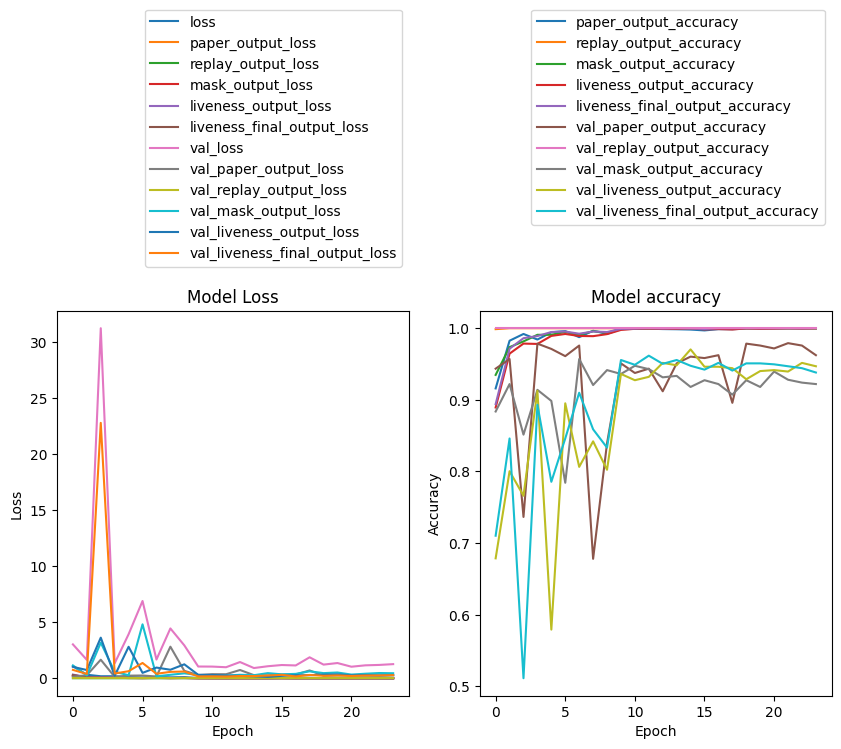

In [ ]:
loss_metrics = [x for x in history.history.keys() if 'loss' in x]
acc_metrics = [x for x in history.history.keys() if 'accuracy' in x]

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
for metric in loss_metrics:
    plt.plot(history.history[metric], label=metric)

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loss_metrics, bbox_to_anchor=(1.00, 1.80))

plt.subplot(1, 2, 2)
for metric in acc_metrics:
    plt.plot(history.history[metric], label=metric)

plt.title('Model accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(acc_metrics, bbox_to_anchor=(1.00, 1.80))

plt.show()

# Predict

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)
val_generator = val_datagen.flow_from_dataframe(
    val,
    PATH_DIR,
    x_col='full_path_iqa',
    y_col=['paper_label', 'mask_label', 'replay_label', 'liveness_label', 'liveness_final_label'],
    target_size=IMG_SIZE,
    class_mode='multi_output',
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 1500 validated image filenames.


In [ ]:
predict_test = model.predict(val_generator, verbose=1)

94/94 [==============================] - 21s 205ms/step


In [ ]:
val['paper_pred'] = predict_test[0].tolist()
val['mask_pred'] = predict_test[1].tolist()
val['replay_pred'] = predict_test[2].tolist()
val['liveness_pred'] = predict_test[3].tolist()
val['liveness_final_pred'] = predict_test[4].tolist()
val.to_csv(f'/content/gdrive/MyDrive/PhD_Models/PhDresults/PhD3_protIntra_trMSU_valMSU_min.csv', index=False)
val.head(3)

<ipython-input-37-cd36e6ef5197>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val['paper_pred'] = predict_test[0].tolist()
<ipython-input-37-cd36e6ef5197>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val['mask_pred'] = predict_test[1].tolist()
<ipython-input-37-cd36e6ef5197>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/s

,frame,scene,client,label,data_type,full_path,distortion_type,full_path_iqa,paper_label,mask_label,replay_label,liveness_label,liveness_final_label,paper_pred,mask_pred,replay_pred,liveness_pred,liveness_final_pred
8500,frame_183.jpg,attack_client035_android_SD_iphone_video_scene01,client035,attack,test,faces/test/attack/attack_client035_android_SD_...,original,faces/test/attack/attack_client035_android_SD_...,"[1.0, 0.0]","[0.0, 1.0]","[0.0, 1.0]","[1.0, 0.0]","[1.0, 0.0]","[1.0, 1.9691406491495478e-11]","[4.895309418245786e-12, 1.0]","[7.525632948843924e-14, 1.0]","[1.0, 1.7442287738317764e-15]","[1.0, 7.659077907486156e-13]"
8501,frame_201.jpg,real_client051_laptop_SD_scene01,client051,real,test,faces/test/real/real_client051_laptop_SD_scene...,original,faces/test/real/real_client051_laptop_SD_scene...,"[0.0, 1.0]","[0.0, 1.0]","[0.0, 1.0]","[0.0, 1.0]","[0.0, 1.0]","[3.5816285048895224e-08, 1.0]","[5.3423749798997555e-12, 1.0]","[0.9999068975448608, 9.311777830589563e-05]","[8.294561553157109e-07, 0.9999991655349731]","[0.04721814766526222, 0.9527818560600281]"
8502,frame_59.jpg,attack_client033_laptop_SD_ipad_video_scene01,client033,attack,test,faces/test/attack/attack_client033_laptop_SD_i...,original,faces/test/attack/attack_client033_laptop_SD_i...,"[1.0, 0.0]","[0.0, 1.0]","[0.0, 1.0]","[1.0, 0.0]","[1.0, 0.0]","[0.9988142251968384, 0.001185818575322628]","[1.04999743708728e-12, 1.0]","[4.439094924979514e-10, 1.0]","[1.0, 4.332698089193343e-11]","[1.0, 3.6659613122935752e-09]"


END